# CAMB Linear Power Spectrum Emulator: Evaluation

This notebook evaluates the trained CosmoPower emulator on held-out test data
and reproduces Figure 2 from the [CosmoPower paper (Spurio Mancini et al. 2022)](https://arxiv.org/abs/2106.03846).

**Emulator details:**
- Architecture: 4 hidden layers x 512 nodes
- Training data: 16M samples (200k cosmologies x 100 redshifts)
- Parameters: h0, omega_m, omega_b, n_s, log1e10As, mnu, z
- Output: log10 P(k) at 200 k-modes, k in [1e-5, 50] h/Mpc

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
from cosmopower import cosmopower_NN

%matplotlib inline

plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 14,
    'figure.figsize': (10, 6),
    'figure.dpi': 120,
})

## 1. Load model and test data

In [2]:
MODEL_PARAMETERS = ['h0', 'omega_m', 'omega_b', 'n_s', 'log1e10As', 'mnu', 'z']
DATA_DIR = './training_data'

# Load model
cp_nn = cosmopower_NN(
    parameters=MODEL_PARAMETERS,
    modes=np.load(f'{DATA_DIR}/camb_linear_modes.npy'),
    n_hidden=[512, 512, 512, 512],
    verbose=False,
    restore=True,
    restore_filename='camb_linear_emulator',
)

# Load test data
modes = np.load(f'{DATA_DIR}/camb_linear_modes.npy')  # k in h/Mpc
test_params = np.load(f'{DATA_DIR}/camb_linear_params_test.npy')
test_logpower_true = np.load(f'{DATA_DIR}/camb_linear_logpower_test.npy')

print(f'Test samples: {len(test_params):,}')
print(f'k-modes: {len(modes)} in [{modes.min():.1e}, {modes.max():.1f}] h/Mpc')
print(f'\nParameter ranges:')
for i, name in enumerate(MODEL_PARAMETERS):
    print(f'  {name:12s}: [{test_params[:, i].min():.4f}, {test_params[:, i].max():.4f}]')

Test samples: 3,999,174
k-modes: 200 in [1.0e-05, 50.0] h/Mpc

Parameter ranges:
  h0          : [0.4000, 1.0000]
  omega_m     : [0.0200, 1.0000]
  omega_b     : [0.0500, 0.0600]
  n_s         : [0.8700, 1.0700]
  log1e10As   : [-3.0000, 6.9999]
  mnu         : [0.0000, 0.2000]
  z           : [0.0000, 2.0000]


## 2. Run predictions on full test set

In [3]:
# Predict in batches
BATCH = 50000
n_test = len(test_params)
predictions = []
for i in range(0, n_test, BATCH):
    batch_params = {name: test_params[i:i+BATCH, j]
                    for j, name in enumerate(MODEL_PARAMETERS)}
    predictions.append(cp_nn.predictions_np(batch_params))
test_logpower_pred = np.concatenate(predictions, axis=0)

print(f'Predictions shape: {test_logpower_pred.shape}')

/global/homes/j/jesteves/.local/perlmutter/tensorflow2.15.0/lib/python3.9/site-packages/cosmopower/cosmopower_NN.py:378: RuntimeWarning: overflow encountered in exp
  layers.append((self.betas_[i] + (1.-self.betas_[i])*1./(1.+np.exp(-self.alphas_[i]*act[-1])))*act[-1])


Predictions shape: (3999174, 200)


## 3. Overall accuracy statistics

In [4]:
# Residuals in log space
residuals = test_logpower_pred - test_logpower_true

# Fractional error: |10^(pred-true) - 1| = |P_pred/P_true - 1|
frac_error = np.abs(np.power(10.0, np.clip(residuals, -30, 30)) - 1.0)

# Summary statistics
print('Full test set accuracy')
print('=' * 50)
print(f'  RMSE [log10 P(k)]:    {np.sqrt(np.mean(residuals**2)):.6f}')
print(f'  Mean |residual|:      {np.mean(np.abs(residuals)):.6f}')
print()
print(f'  Fractional error |dP/P|:')
print(f'    median:             {np.median(frac_error):.4%}')
print(f'    68th percentile:    {np.percentile(frac_error, 68):.4%}')
print(f'    95th percentile:    {np.percentile(frac_error, 95):.4%}')
print(f'    99th percentile:    {np.percentile(frac_error, 99):.4%}')
print()
print(f'  Samples within accuracy:')
for thresh in [0.001, 0.005, 0.01, 0.05, 0.10]:
    frac = np.mean(frac_error < thresh) * 100
    print(f'    |dP/P| < {thresh:.1%}:      {frac:.1f}%')

Full test set accuracy


  RMSE [log10 P(k)]:    0.039825


  Mean |residual|:      0.004796

  Fractional error |dP/P|:


    median:             0.2612%


    68th percentile:    0.4468%


...

    |dP/P| < 0.1%:      22.2%


    |dP/P| < 0.5%:      71.3%


    |dP/P| < 1.0%:      86.3%


    |dP/P| < 5.0%:      97.7%


    |dP/P| < 10.0%:      98.8%


## 4. Reproduce CosmoPower Figure 2

Figure 2 of [Spurio Mancini et al. (2022)](https://arxiv.org/abs/2106.03846) shows the
fractional absolute emulator error |P_emul - P_true| / P_true as a function of
wavenumber k, with 68th, 95th, and 99th percentile bands.

**Key differences between our emulator and the paper:**

| | CosmoPower (2022) | This work |
|---|---|---|
| Parameters | omega_b, omega_cdm (physical) | Omega_m, Omega_b (fractions) |
| h range | [0.64, 0.82] | [0.4, 1.0] |
| z range | [0, 5] | [0, 2] |
| k units | Mpc^-1 | h/Mpc |
| k range | [1e-5, 10] Mpc^-1 | [1e-5, 50] h/Mpc |
| Training samples | 180k | 16M |
| log transform | ln P(k) | log10 P(k) |
| Neutrino mass | not included | [0, 0.2] eV |

For a fairer comparison, we select a subset of our test data whose derived
physical parameters fall within the CosmoPower paper ranges.

In [5]:
# Our parameters: h0, omega_m (Omega_m), omega_b (Omega_b), n_s, log1e10As, mnu, z
# CosmoPower uses: omega_b = Omega_b * h^2, omega_cdm = (Omega_m - Omega_b) * h^2

h0 = test_params[:, 0]
Omega_m = test_params[:, 1]
Omega_b = test_params[:, 2]
n_s = test_params[:, 3]
log1e10As = test_params[:, 4]  # log10(1e10 * As)
mnu = test_params[:, 5]
z = test_params[:, 6]

# Derived physical densities
omega_b_phys = Omega_b * h0**2       # omega_b = Omega_b * h^2
omega_cdm_phys = (Omega_m - Omega_b) * h0**2  # omega_cdm = (Omega_m - Omega_b) * h^2

# Convert log1e10As (base 10) to ln(1e10 As)
# log10(1e10 As) = x  =>  1e10 As = 10^x  =>  ln(1e10 As) = x * ln(10)
ln1e10As = log1e10As * np.log(10)

# CosmoPower paper ranges (Table 1)
mask = (
    (omega_b_phys >= 0.01875) & (omega_b_phys <= 0.02625) &
    (omega_cdm_phys >= 0.05) & (omega_cdm_phys <= 0.255) &
    (h0 >= 0.64) & (h0 <= 0.82) &
    (n_s >= 0.84) & (n_s <= 1.1) &
    (ln1e10As >= 1.61) & (ln1e10As <= 3.91) &
    (z <= 2.0)  # our max is 2, paper goes to 5
)

print(f'Samples matching CosmoPower ranges: {mask.sum():,} / {len(mask):,} ({mask.mean():.1%})')
print(f'\nDerived parameter ranges in subset:')
print(f'  omega_b (phys):  [{omega_b_phys[mask].min():.5f}, {omega_b_phys[mask].max():.5f}]')
print(f'  omega_cdm (phys):[{omega_cdm_phys[mask].min():.5f}, {omega_cdm_phys[mask].max():.5f}]')
print(f'  h:               [{h0[mask].min():.4f}, {h0[mask].max():.4f}]')
print(f'  n_s:             [{n_s[mask].min():.4f}, {n_s[mask].max():.4f}]')
print(f'  ln(1e10 As):     [{ln1e10As[mask].min():.4f}, {ln1e10As[mask].max():.4f}]')
print(f'  mnu:             [{mnu[mask].min():.4f}, {mnu[mask].max():.4f}]')
print(f'  z:               [{z[mask].min():.4f}, {z[mask].max():.4f}]')

Samples matching CosmoPower ranges: 16,500 / 3,999,174 (0.4%)

Derived parameter ranges in subset:
  omega_b (phys):  [0.02072, 0.02619]
  omega_cdm (phys):[0.05277, 0.25378]
  h:               [0.6401, 0.7126]
  n_s:             [0.8724, 1.0653]
  ln(1e10 As):     [1.6266, 3.9075]
  mnu:             [0.0013, 0.1995]
  z:               [0.0000, 2.0000]


In [6]:
def plot_error_vs_k(frac_err, k_modes, title, ax=None, k_unit='h/Mpc'):
    """Reproduce CosmoPower Figure 2 style: percentile bands vs k."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    # Percentiles per k-mode
    pct68 = np.percentile(frac_err, 68, axis=0) * 100
    pct95 = np.percentile(frac_err, 95, axis=0) * 100
    pct99 = np.percentile(frac_err, 99, axis=0) * 100

    ax.fill_between(k_modes, 0, pct99, color='#FDCCCC', label='99th percentile')
    ax.fill_between(k_modes, 0, pct95, color='#E85050', label='95th percentile')
    ax.fill_between(k_modes, 0, pct68, color='#8B0000', label='68th percentile')

    ax.set_xscale('log')
    ax.set_xlabel(f'k [{k_unit}]')
    ax.set_ylabel('Fractional error |dP/P| [%]')
    ax.set_title(title)
    ax.legend(loc='upper left')
    ax.set_xlim(k_modes.min(), k_modes.max())
    ax.set_ylim(bottom=0)

    return ax

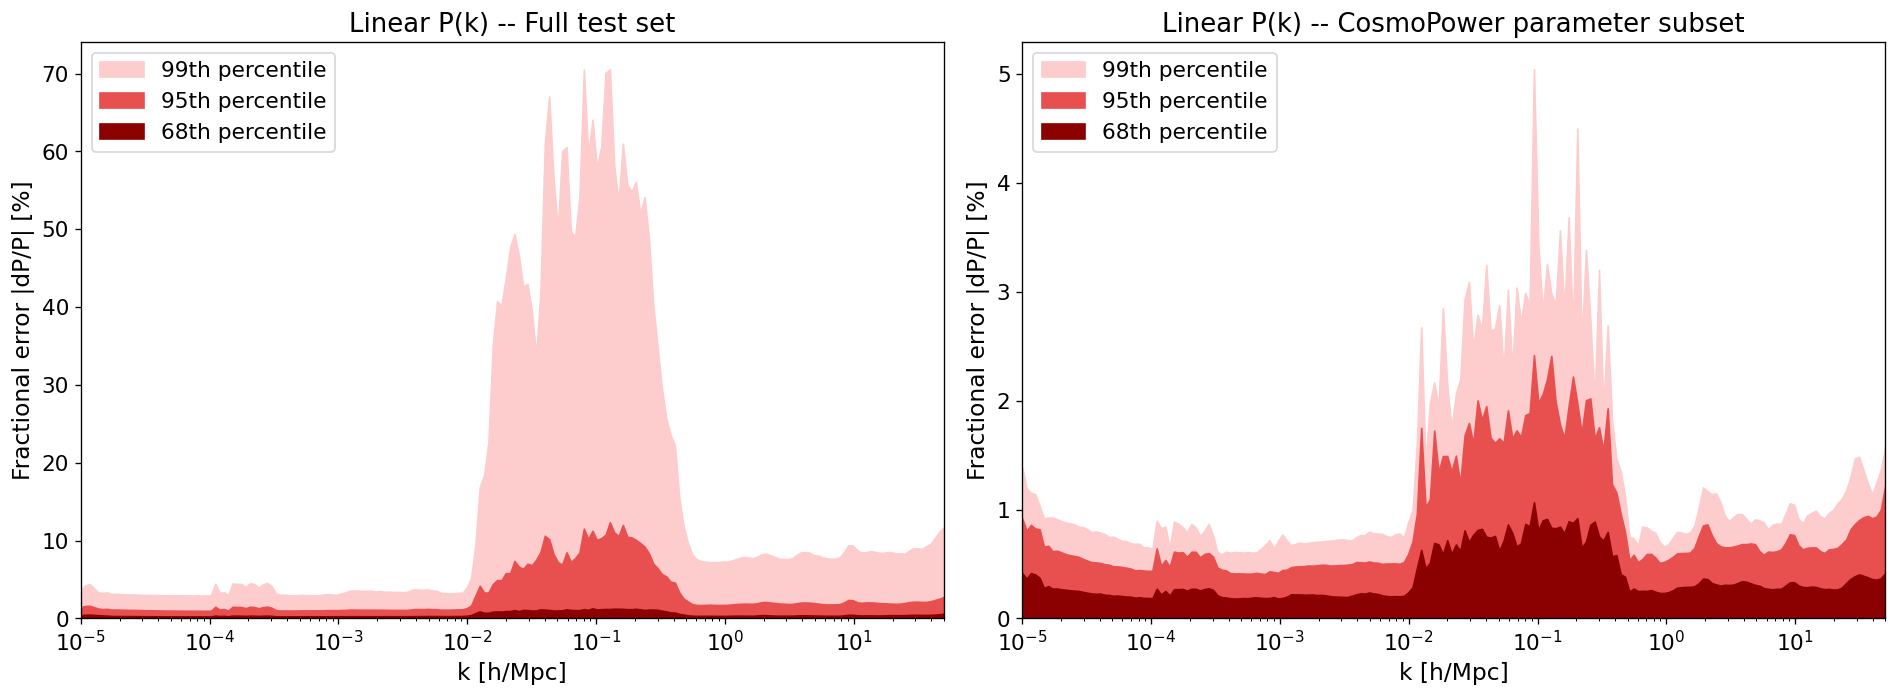

Metric                            Full test    CP subset     CP paper
--------------------------------------------------------------------


  68th pct |dP/P|                   0.4468%      0.3284%       <0.05%


  95th pct |dP/P|                   2.4535%      1.0123%       <0.08%


  99th pct |dP/P|                  12.6725%      1.8317%        <0.1%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel (a): Full test set
plot_error_vs_k(frac_error, modes,
                'Linear P(k) -- Full test set', ax=axes[0])

# Panel (b): CosmoPower-like subset
frac_error_subset = frac_error[mask]
plot_error_vs_k(frac_error_subset, modes,
                'Linear P(k) -- CosmoPower parameter subset', ax=axes[1])

fig.tight_layout()
fig.savefig('plots/fig2_error_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

# Print comparison stats
print(f'{"Metric":<30s} {"Full test":>12s} {"CP subset":>12s} {"CP paper":>12s}')
print('-' * 68)
for label, pct in [('68th pct |dP/P|', 68), ('95th pct |dP/P|', 95), ('99th pct |dP/P|', 99)]:
    val_full = np.percentile(frac_error, pct) * 100
    val_sub = np.percentile(frac_error_subset, pct) * 100
    cp_ref = {'68th pct |dP/P|': '<0.05%', '95th pct |dP/P|': '<0.08%', '99th pct |dP/P|': '<0.1%'}[label]
    print(f'  {label:<28s} {val_full:>11.4f}% {val_sub:>11.4f}% {cp_ref:>12s}')

## 5. Per-k-mode accuracy

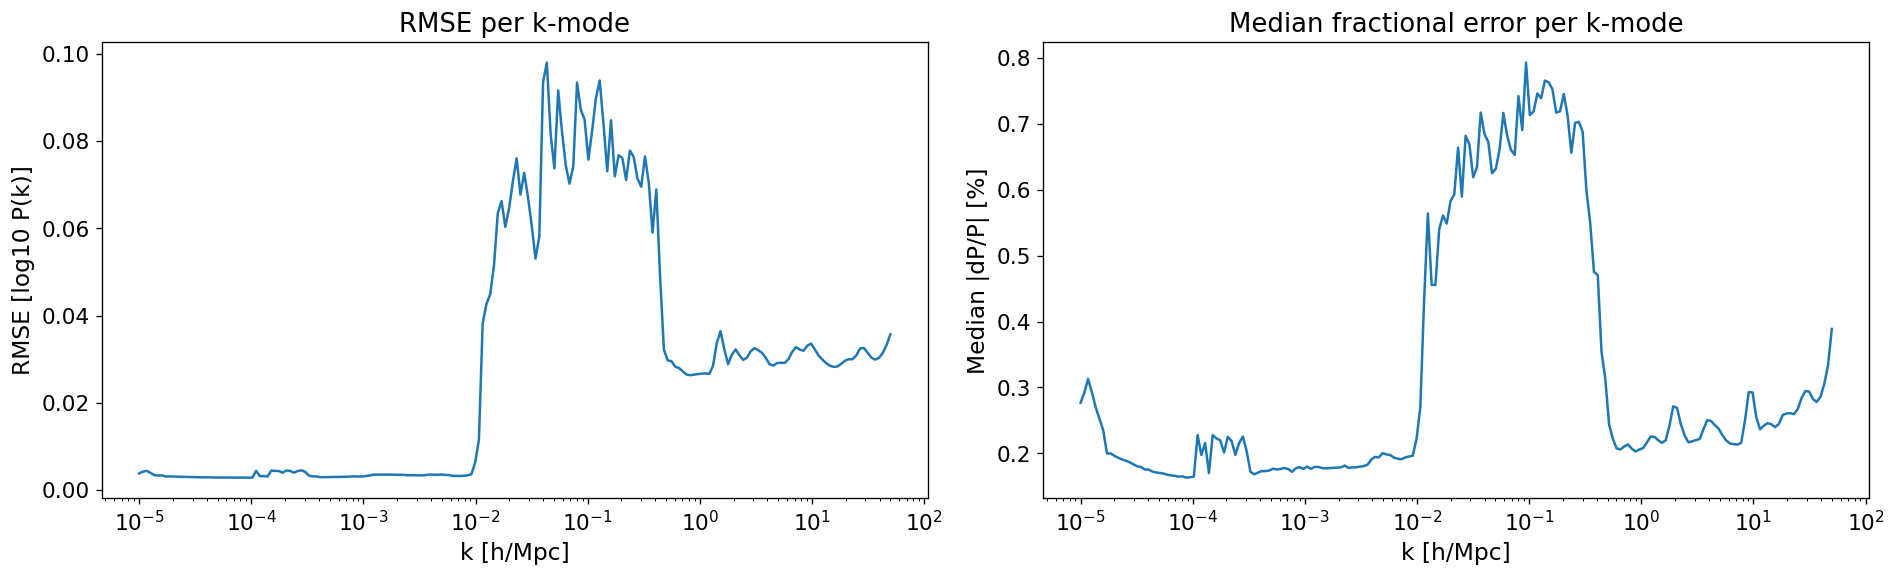

Best  k-mode: k=8.7613e-05 h/Mpc, RMSE=0.002840
Worst k-mode: k=4.3214e-02 h/Mpc, RMSE=0.098016


In [8]:
rmse_per_mode = np.sqrt(np.mean(residuals**2, axis=0))
median_frac_per_mode = np.median(frac_error, axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(modes, rmse_per_mode)
axes[0].set_xscale('log')
axes[0].set_xlabel('k [h/Mpc]')
axes[0].set_ylabel('RMSE [log10 P(k)]')
axes[0].set_title('RMSE per k-mode')

axes[1].plot(modes, median_frac_per_mode)
axes[1].set_xscale('log')
axes[1].set_xlabel('k [h/Mpc]')
axes[1].set_ylabel('Median |dP/P| [%]')
axes[1].set_title('Median fractional error per k-mode')

fig.tight_layout()
fig.savefig('plots/error_per_kmode.png', dpi=150, bbox_inches='tight')
plt.show()

# Worst and best modes
print(f'Best  k-mode: k={modes[np.argmin(rmse_per_mode)]:.4e} h/Mpc, RMSE={rmse_per_mode.min():.6f}')
print(f'Worst k-mode: k={modes[np.argmax(rmse_per_mode)]:.4e} h/Mpc, RMSE={rmse_per_mode.max():.6f}')

## 6. Accuracy vs redshift

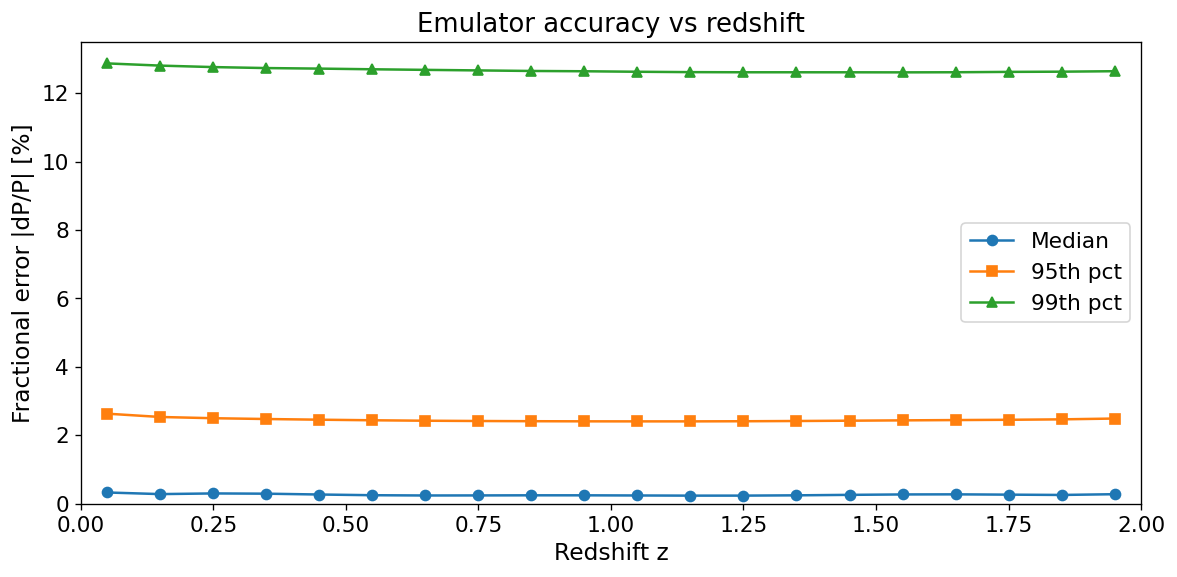

In [9]:
# Bin by redshift
z_vals = test_params[:, 6]
z_bins = np.linspace(0, 2, 21)
z_centers = 0.5 * (z_bins[:-1] + z_bins[1:])

median_by_z = []
pct95_by_z = []
pct99_by_z = []

for zlo, zhi in zip(z_bins[:-1], z_bins[1:]):
    zmask = (z_vals >= zlo) & (z_vals < zhi)
    if zmask.sum() == 0:
        median_by_z.append(np.nan)
        pct95_by_z.append(np.nan)
        pct99_by_z.append(np.nan)
        continue
    fe = frac_error[zmask]
    median_by_z.append(np.median(fe) * 100)
    pct95_by_z.append(np.percentile(fe, 95) * 100)
    pct99_by_z.append(np.percentile(fe, 99) * 100)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(z_centers, median_by_z, 'o-', label='Median')
ax.plot(z_centers, pct95_by_z, 's-', label='95th pct')
ax.plot(z_centers, pct99_by_z, '^-', label='99th pct')
ax.set_xlabel('Redshift z')
ax.set_ylabel('Fractional error |dP/P| [%]')
ax.set_title('Emulator accuracy vs redshift')
ax.legend()
ax.set_xlim(0, 2)
ax.set_ylim(bottom=0)
fig.tight_layout()
fig.savefig('plots/error_vs_redshift.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Example spectra comparison

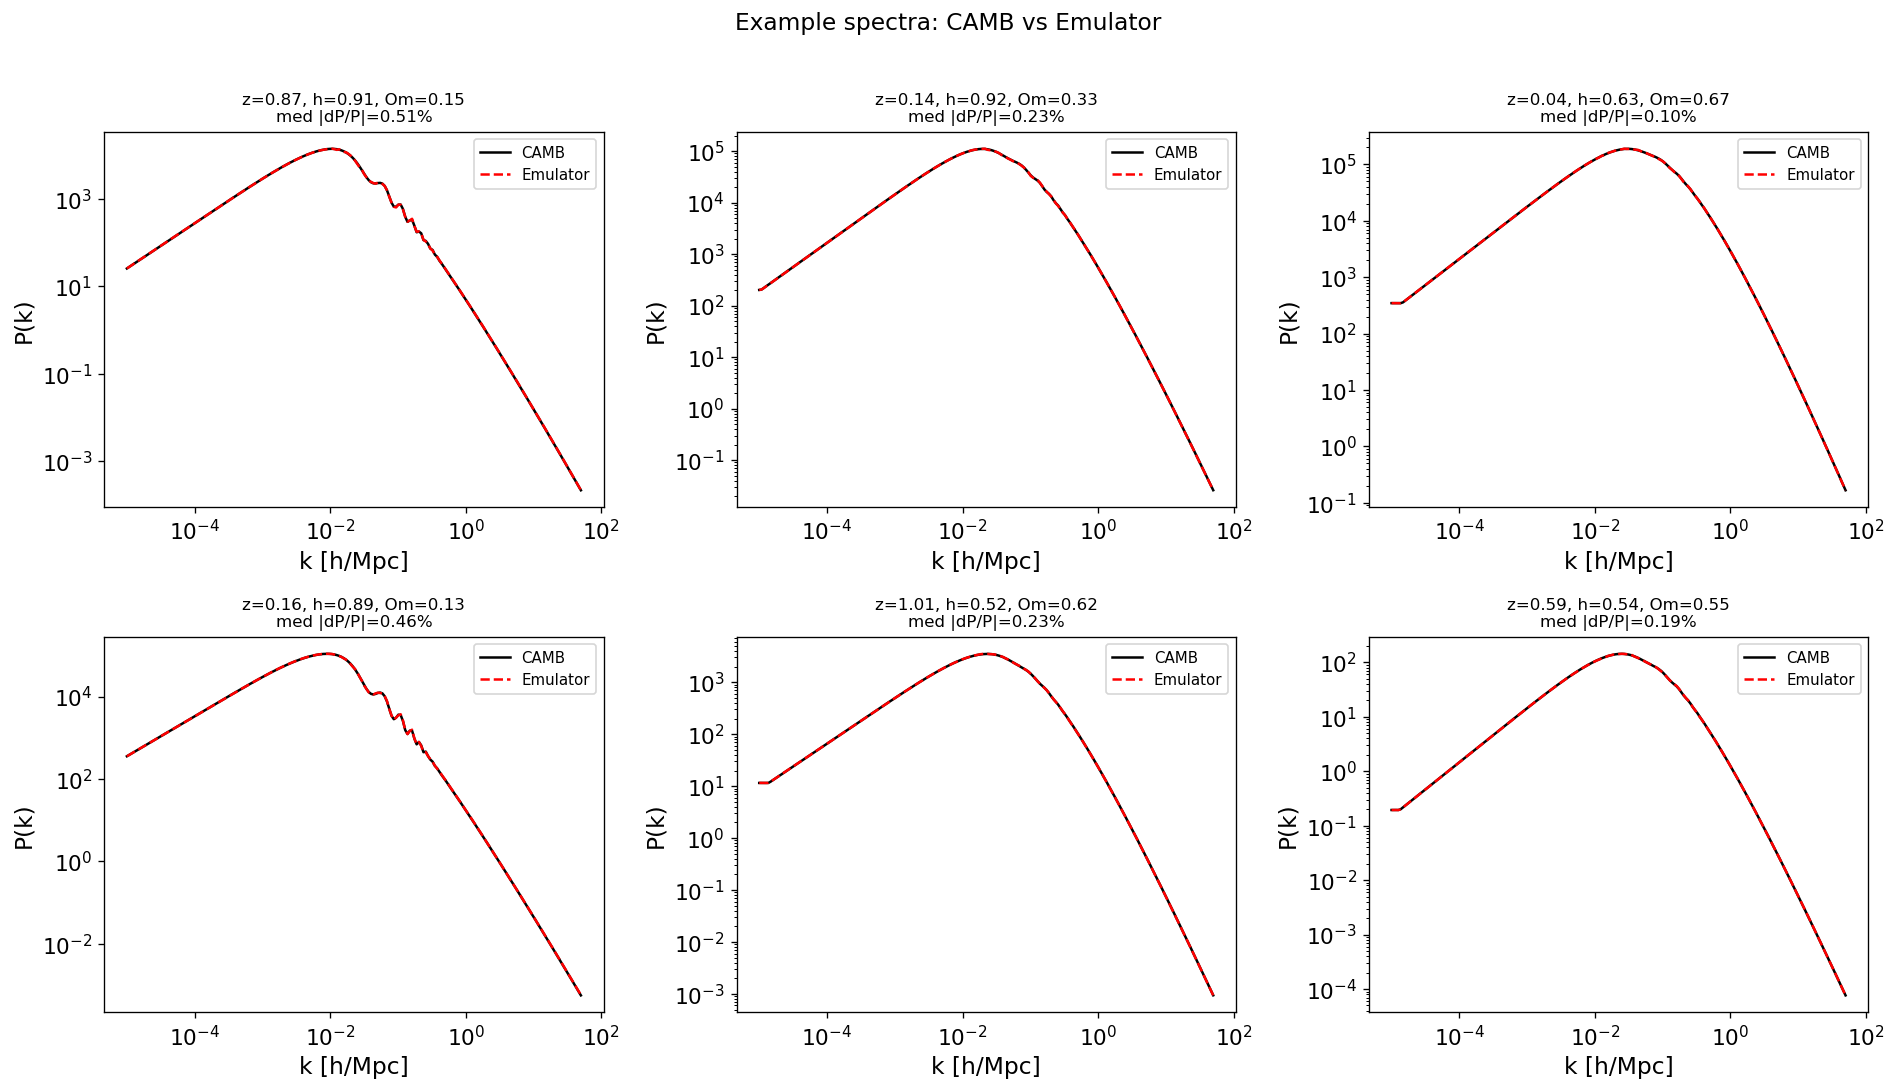

In [10]:
# Pick a few random test samples
rng = np.random.default_rng(42)
idx = rng.choice(n_test, 6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, ii in zip(axes.flat, idx):
    ax.plot(modes, 10**test_logpower_true[ii], 'k-', lw=1.5, label='CAMB')
    ax.plot(modes, 10**test_logpower_pred[ii], 'r--', lw=1.5, label='Emulator')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('k [h/Mpc]')
    ax.set_ylabel('P(k)')
    p = test_params[ii]
    err = np.median(frac_error[ii]) * 100
    ax.set_title(f'z={p[6]:.2f}, h={p[0]:.2f}, Om={p[1]:.2f}\nmed |dP/P|={err:.2f}%',
                 fontsize=10)
    ax.legend(fontsize=9)

fig.suptitle('Example spectra: CAMB vs Emulator', fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig('plots/example_spectra.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary

In [11]:
print('Emulator Evaluation Summary')
print('=' * 60)
print(f'Model: camb_linear_emulator (4x512, 3-phase training)')
print(f'Training data: 15,996,528 samples')
print(f'Test data: {n_test:,} samples')
print(f'k range: [{modes.min():.1e}, {modes.max():.1f}] h/Mpc ({len(modes)} modes)')
print(f'z range: [0, 2]')
print()
print(f'{"":<30s} {"Full test":>12s} {"CP subset":>12s}')
print('-' * 56)
print(f'{"N samples":<30s} {n_test:>12,} {mask.sum():>12,}')
print(f'{"RMSE [log10 P(k)]":<30s} {np.sqrt(np.mean(residuals**2)):>12.6f} {np.sqrt(np.mean(residuals[mask]**2)):>12.6f}')
print(f'{"Median |dP/P|":<30s} {np.median(frac_error)*100:>11.4f}% {np.median(frac_error[mask])*100:>11.4f}%')
print(f'{"95th pct |dP/P|":<30s} {np.percentile(frac_error,95)*100:>11.4f}% {np.percentile(frac_error[mask],95)*100:>11.4f}%')
print(f'{"99th pct |dP/P|":<30s} {np.percentile(frac_error,99)*100:>11.4f}% {np.percentile(frac_error[mask],99)*100:>11.4f}%')
print(f'{"Samples < 1% error":<30s} {np.mean(frac_error<0.01)*100:>11.1f}% {np.mean(frac_error[mask]<0.01)*100:>11.1f}%')
print(f'{"Samples < 5% error":<30s} {np.mean(frac_error<0.05)*100:>11.1f}% {np.mean(frac_error[mask]<0.05)*100:>11.1f}%')

Emulator Evaluation Summary
Model: camb_linear_emulator (4x512, 3-phase training)
Training data: 15,996,528 samples
Test data: 3,999,174 samples
k range: [1.0e-05, 50.0] h/Mpc (200 modes)
z range: [0, 2]

                                  Full test    CP subset
--------------------------------------------------------
N samples                         3,999,174       16,500


RMSE [log10 P(k)]                  0.039825     0.002146


Median |dP/P|                       0.2612%      0.2048%


95th pct |dP/P|                     2.4535%      1.0123%


99th pct |dP/P|                    12.6725%      1.8317%


Samples < 1% error                    86.3%        94.9%


Samples < 5% error                    97.7%       100.0%
